<a href="https://colab.research.google.com/github/manasuii/Python-Learning-Based-Mini-Projects/blob/main/MLP_PINN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Smooth bimetallic reference solution
  N=200, T=100, dx=0.00503
  c1=1.0, c2=1.5, center=0.5, width=0.03
  c at x=0.0: 1.0000
  c at x=0.5: 1.2605
  c at x=1.0: 1.5000

Solving... (~10-30 seconds)
Solved. Shape: (100, 200)
u range: [-0.9641, 1.0000]

Saved: u_ref_smooth.npy, x_nodes_smooth.npy, t_eval_smooth.npy


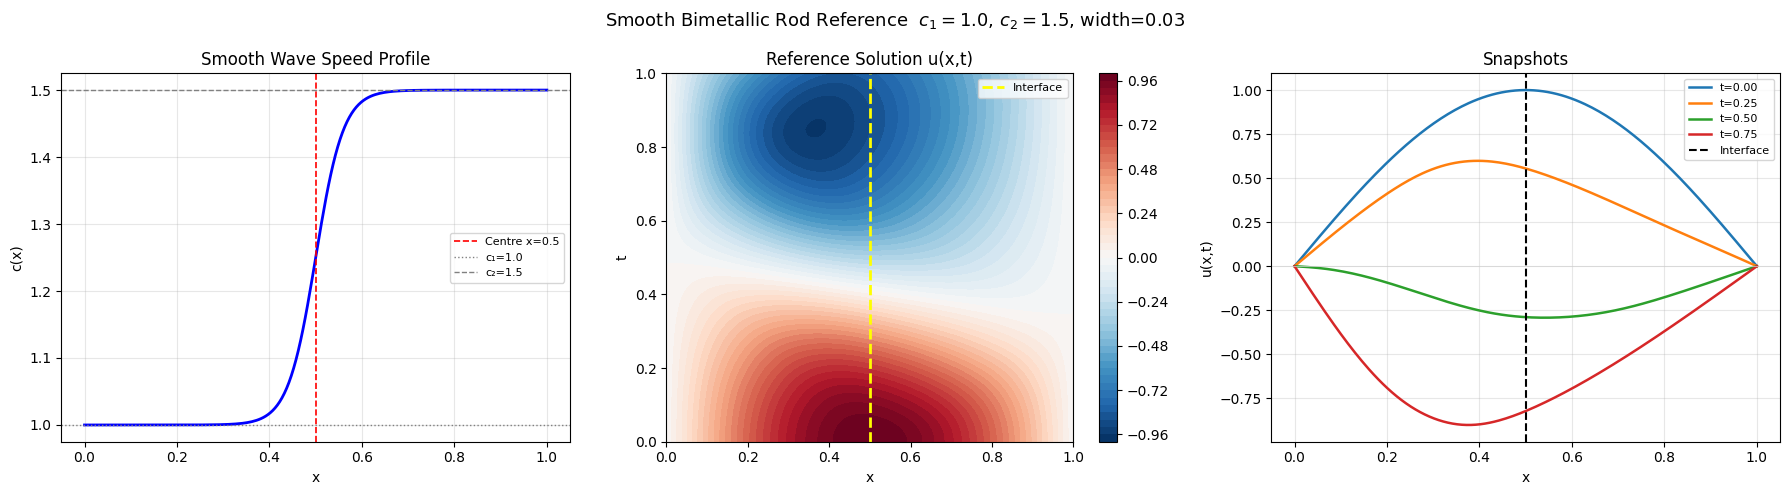


Sanity checks:
  u(x,0) max = 1.0000  (should be ~1.0)
  Asymmetry at t=0.5: 0.0516  (>0 means interface effect visible)

✅ Done. Now run: python wave_gnn_pinn_v5_smooth.py


In [1]:
"""
step1_reference_smooth.py
=====================================================================
Generates numerical ground truth for the SMOOTH bimetallic rod.
Must be run before wave_gnn_pinn_v5_smooth.py.

Uses method of lines + scipy RK45.
c(x) = c1 + (c2-c1) * sigmoid((x-0.5)/width)

OUTPUT
──────
  u_ref_smooth.npy
  x_nodes_smooth.npy
  t_eval_smooth.npy
  reference_smooth.png
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.special import expit     # stable sigmoid

# ── Parameters ───────────────────────────────────────────────
N         = 200
T_EVAL    = 100
C1        = 1.0
C2        = 1.5
CENTER    = 0.5
WIDTH     = 0.03      # must match v5 hyperparameter

x_nodes   = np.linspace(0, 1, N)
t_eval    = np.linspace(0, 1, T_EVAL)
dx        = x_nodes[1] - x_nodes[0]

# ── Smooth wave speed field ───────────────────────────────────
c_field   = C1 + (C2 - C1) * expit((x_nodes - CENTER) / WIDTH)

print("Smooth bimetallic reference solution")
print(f"  N={N}, T={T_EVAL}, dx={dx:.5f}")
print(f"  c1={C1}, c2={C2}, center={CENTER}, width={WIDTH}")
print(f"  c at x=0.0: {c_field[0]:.4f}")
print(f"  c at x=0.5: {c_field[N//2]:.4f}")
print(f"  c at x=1.0: {c_field[-1]:.4f}")

# ── Initial conditions ────────────────────────────────────────
u0     = np.sin(np.pi * x_nodes)
v0     = np.zeros(N)
state0 = np.concatenate([u0, v0])

# ── Method of lines RHS ──────────────────────────────────────
def wave_rhs(t, state):
    u    = state[:N]
    v    = state[N:]
    u_xx = np.zeros(N)
    u_xx[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
    u_xx[0]    = 0.0
    u_xx[-1]   = 0.0
    dudt = v
    dvdt = c_field**2 * u_xx
    return np.concatenate([dudt, dvdt])

# ── Solve ─────────────────────────────────────────────────────
print("\nSolving... (~10-30 seconds)")
sol = solve_ivp(
    wave_rhs,
    t_span  = [0.0, 1.0],
    y0      = state0,
    t_eval  = t_eval,
    method  = 'RK45',
    rtol    = 1e-8,
    atol    = 1e-8,
)

if not sol.success:
    raise RuntimeError(f"Solver failed: {sol.message}")

u_ref = sol.y[:N, :].T    # [T, N]
print(f"Solved. Shape: {u_ref.shape}")
print(f"u range: [{u_ref.min():.4f}, {u_ref.max():.4f}]")

# ── Save ──────────────────────────────────────────────────────
np.save("u_ref_smooth.npy",    u_ref)
np.save("x_nodes_smooth.npy",  x_nodes)
np.save("t_eval_smooth.npy",   t_eval)
print("\nSaved: u_ref_smooth.npy, x_nodes_smooth.npy, t_eval_smooth.npy")

# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Wave speed profile
axes[0].plot(x_nodes, c_field, 'b-', lw=2)
axes[0].axvline(CENTER, color='red', ls='--', lw=1.2,
                label=f'Centre x={CENTER}')
axes[0].axhline(C1, color='gray', ls=':', lw=1, label=f'c₁={C1}')
axes[0].axhline(C2, color='gray', ls='--', lw=1, label=f'c₂={C2}')
axes[0].set_xlabel("x"); axes[0].set_ylabel("c(x)")
axes[0].set_title("Smooth Wave Speed Profile")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Heatmap
X2d, T2d = np.meshgrid(x_nodes, t_eval)
cf = axes[1].contourf(X2d, T2d, u_ref, levels=60, cmap='RdBu_r')
axes[1].axvline(x=CENTER, color='yellow', lw=2,
                ls='--', label='Interface')
axes[1].set_xlabel("x"); axes[1].set_ylabel("t")
axes[1].set_title("Reference Solution u(x,t)")
axes[1].legend(fontsize=8)
plt.colorbar(cf, ax=axes[1])

# Snapshots
snap_times = [0.0, 0.25, 0.50, 0.75]
colors     = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']
for ts, col in zip(snap_times, colors):
    idx = np.argmin(np.abs(t_eval - ts))
    axes[2].plot(x_nodes, u_ref[idx],
                 color=col, lw=1.8, label=f't={ts:.2f}')
axes[2].axvline(CENTER, color='black', lw=1.5,
                ls='--', label='Interface')
axes[2].axhline(0, color='lightgray', lw=0.5)
axes[2].set_xlabel("x"); axes[2].set_ylabel("u(x,t)")
axes[2].set_title("Snapshots")
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.suptitle(
    f"Smooth Bimetallic Rod Reference  "
    f"$c_1={C1}$, $c_2={C2}$, width={WIDTH}",
    fontsize=13)
plt.tight_layout()
plt.savefig("reference_smooth.png", dpi=150, bbox_inches='tight')
plt.show()

# Sanity checks
print("\nSanity checks:")
print(f"  u(x,0) max = {u_ref[0].max():.4f}  (should be ~1.0)")
t_half = np.argmin(np.abs(t_eval - 0.5))
asym   = np.abs(u_ref[t_half, :N//2].mean() -
                u_ref[t_half, N//2:].mean())
print(f"  Asymmetry at t=0.5: {asym:.4f}  (>0 means interface effect visible)")
print(f"\n✅ Done. Now run: python wave_gnn_pinn_v5_smooth.py")

In [3]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 83.5 MB/s eta 0:00:00


✅ Reference files found.

MLP-PINN Baseline Training Plan:
  Win |  t_max |  Epochs |      LR
  -----------------------------------
    1 |   0.10 |    3000 |   3e-04
    2 |   0.20 |    3000 |   3e-04
    3 |   0.35 |    4000 |   3e-04
    4 |   0.50 |    4000 |   3e-04
    5 |   0.65 |    5000 |   3e-04
    6 |   0.80 |   15000 |   1e-04 ← BOOSTED
    7 |   1.00 |   20000 |   1e-04 ← BOOSTED

  Total epochs: 54,000

c1=1.0, c2=1.5 | R=0.200, T=0.800

Loading reference solution...
  Reference loaded: (100, 200)

Estimating runtime...
  Per epoch  : 2.00 sec
  Est. total : 30.0 hrs (1803 min)

MLP-PINN parameters: 121,987

  WINDOW 1/7:  t∈[0,0.10]  epochs=3000  lr=3e-04
     Ep|    Total|      PDE|      BC|      IC|      Amp|       u range|       ETA
-------------------------------------------------------------------------------------
      1| 262.8378| 91.31952| 0.83669| 2.40013|  0.70286|[-0.467,0.387]|   14.8min
    600|   0.2539|  0.08732| 0.00014| 0.00011|  0.00007|[-0.002,0.991]

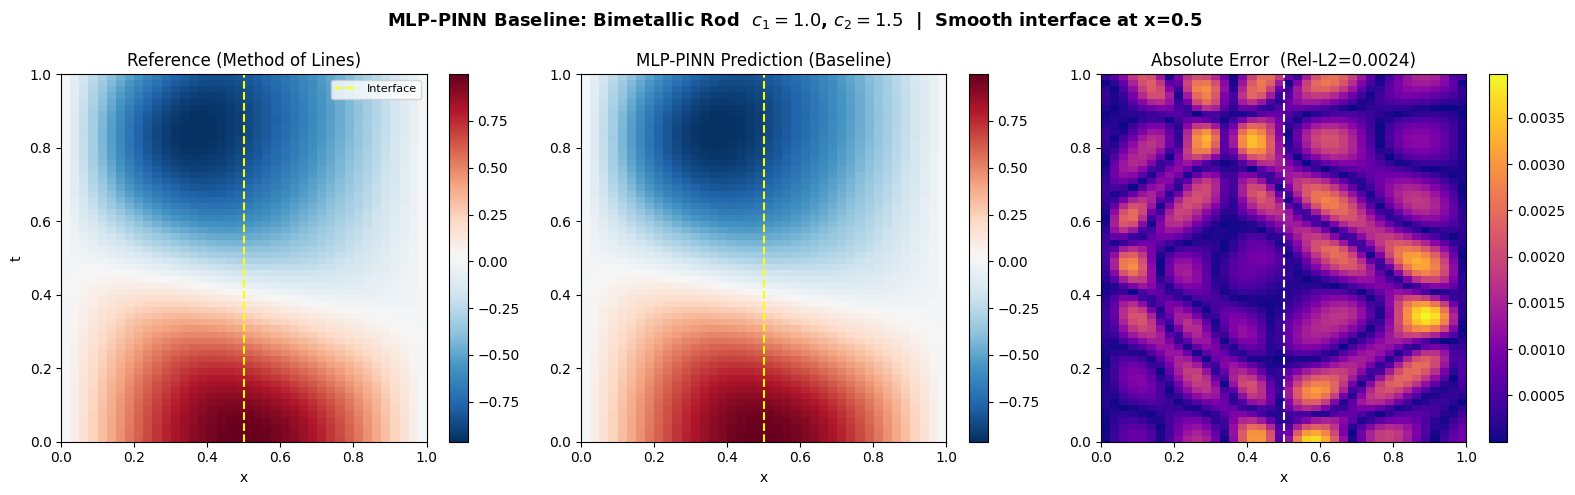

Saved: mlp_result_FINAL.png


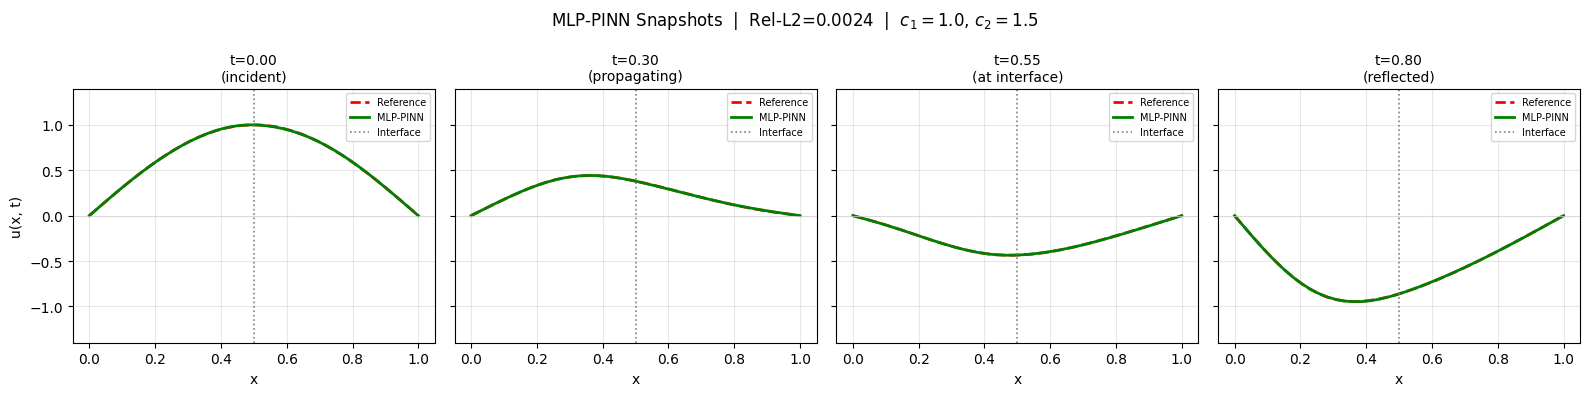

Saved: mlp_snapshots_FINAL.png


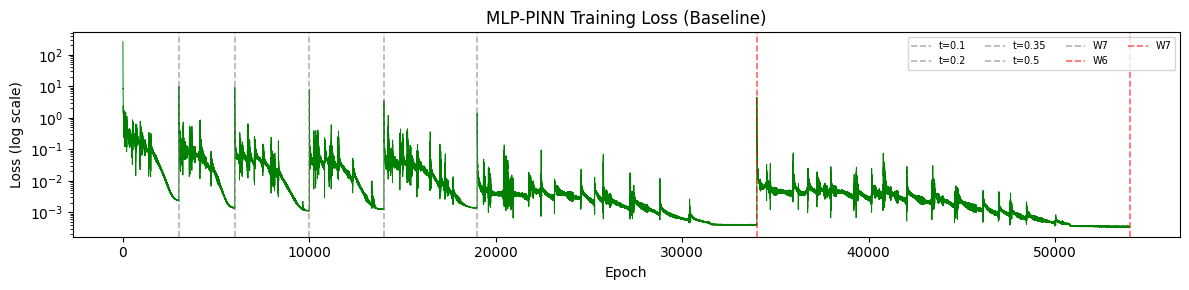

Saved: mlp_loss_FINAL.png

  PAPER TABLE 1: Quantitative Comparison
  Bimetallic Rod  c1=1.0, c2=1.5  (smooth interface)
  Method                        Rel-L2    Max Error     Params
  ------------------------------------------------------------
  MLP-PINN (baseline)          0.00244      0.00397    121,987
  GNN-PINN (ours)           [run FINAL.py]            —          —
  ------------------------------------------------------------
  Fill in GNN-PINN result after wave_gnn_pinn_FINAL.py completes.
  MLP-PINN Rel-L2  : 0.00244
  MLP-PINN Max err : 0.00397
  MLP-PINN params  : 121,987
  Training time    : 252.0 min

Saved: comparison_table.txt
Saved: u_pred_mlp_FINAL.npy

  MLP-PINN BASELINE — COMPLETE
  Rel-L2       : 0.00244
  Max error    : 0.00397
  Train time   : 252.0 min
  Model params : 121,987

Next steps:
  1. Wait for wave_gnn_pinn_FINAL.py to finish
  2. Compare rel_l2 values
  3. Fill [FILL] tags in gnn_pinn_paper.tex
  4. Upload to arXiv


In [4]:
"""
MLP-PINN Baseline — Bimetallic Rod (Smooth Interface)
=====================================================================
IDENTICAL setup to wave_gnn_pinn_FINAL.py EXCEPT:
  - No GNN layers (pure MLP)
  - Same Fourier encoder
  - Same training strategy (causal windows, same epochs)
  - Same loss functions
  - Same reference solution

This is the FAIR BASELINE for your paper Table 1.
Run this in parallel with wave_gnn_pinn_FINAL.py.

RUN ORDER:
  1. python step1_reference_smooth.py   (if not done already)
  2. python mlp_pinn_baseline.py        (parallel with FINAL.py)

OUTPUT FILES:
  mlp_result_FINAL.png
  mlp_snapshots_FINAL.png
  mlp_reflection_FINAL.png
  mlp_loss_FINAL.png
  mlp_model_FINAL.pt
  comparison_table.txt      ← ready to paste into paper
"""

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
import os, time

torch.manual_seed(42)
np.random.seed(42)

# ── Check required files ─────────────────────────────────────
for f in ["u_ref_smooth.npy","x_nodes_smooth.npy","t_eval_smooth.npy"]:
    if not os.path.exists(f):
        raise FileNotFoundError(
            f"\n❌ Missing: {f}"
            f"\nRun step1_reference_smooth.py first.")
print("✅ Reference files found.\n")

# ============================================================
# 1.  HYPERPARAMETERS  (identical to GNN-PINN FINAL)
# ============================================================
N          = 40
T          = 60
C1         = 1.0
C2         = 1.5
CENTER     = 0.5
WIDTH      = 0.03
HIDDEN     = 128
NUM_FREQS  = 24
N_AMP      = 8

# MLP depth chosen to match GNN-PINN parameter count roughly
MLP_DEPTH  = 8      # deeper MLP to compensate for no message passing

# Same window config as GNN-PINN for fair comparison
WINDOW_CONFIG = [
    # (t_max, epochs,  lr,    amp_weight)
    (0.10,   3000,   3e-4,  15.0),
    (0.20,   3000,   3e-4,  15.0),
    (0.35,   4000,   3e-4,  15.0),
    (0.50,   4000,   3e-4,  15.0),
    (0.65,   5000,   3e-4,  15.0),
    (0.80,   15000,  1e-4,  30.0),   # boosted — same as GNN
    (1.00,   20000,  1e-4,  30.0),   # boosted — same as GNN
]

total_epochs = sum(cfg[1] for cfg in WINDOW_CONFIG)
print(f"MLP-PINN Baseline Training Plan:")
print(f"  {'Win':>3} | {'t_max':>6} | {'Epochs':>7} | {'LR':>7}")
print(f"  {'-'*35}")
for i,(tm,ep,lr,aw) in enumerate(WINDOW_CONFIG):
    marker = " ← BOOSTED" if i >= 5 else ""
    print(f"  {i+1:>3} | {tm:>6.2f} | {ep:>7} | {lr:>7.0e}{marker}")
print(f"\n  Total epochs: {total_epochs:,}")

# ============================================================
# 2.  SMOOTH WAVE SPEED FIELD  (identical to GNN-PINN)
# ============================================================
def make_c_smooth(x_nodes, c1=C1, c2=C2,
                  center=CENTER, width=WIDTH):
    return c1 + (c2-c1) * torch.sigmoid(
        (x_nodes - center) / width)

x_nodes       = torch.linspace(0, 1, N)
c_field_nodes = make_c_smooth(x_nodes)
R_approx      = abs(C2-C1) / (C2+C1)
T_approx      = 2*min(C1,C2) / (C2+C1)
print(f"\nc1={C1}, c2={C2} | R={R_approx:.3f}, T={T_approx:.3f}\n")

# ============================================================
# 3.  GRAPH UTILITIES  (still needed for bc/ic losses)
# ============================================================
def build_chain_edges(N):
    src, dst = [], []
    for i in range(N-1):
        src += [i, i+1]; dst += [i+1, i]
    return torch.tensor([src, dst], dtype=torch.long)

def tile_edges(edge_index, N, T):
    return torch.cat([edge_index + t*N for t in range(T)], dim=1)

edge_index_single = build_chain_edges(N)

# ============================================================
# 4.  LOAD REFERENCE SOLUTION  (identical to GNN-PINN)
# ============================================================
print("Loading reference solution...")
u_ref_full = np.load("u_ref_smooth.npy")
x_ref      = np.load("x_nodes_smooth.npy")
t_ref      = np.load("t_eval_smooth.npy")

interp = RegularGridInterpolator(
    (t_ref, x_ref), u_ref_full,
    method='linear', bounds_error=False, fill_value=None)

t_eval_gnn  = np.linspace(0, 1, T)
x_eval_gnn  = x_nodes.numpy()
T_mg, X_mg  = np.meshgrid(t_eval_gnn, x_eval_gnn, indexing='ij')
pts         = np.stack([T_mg.ravel(), X_mg.ravel()], axis=1)
u_exact_gnn = interp(pts).reshape(T, N)
print(f"  Reference loaded: {u_ref_full.shape}\n")

# ============================================================
# 5.  MLP-PINN MODEL
#     KEY DIFFERENCE FROM GNN-PINN:
#     No message passing layers — pure feedforward MLP.
#     Same Fourier encoder for fair comparison.
#     edge_index parameter accepted but ignored.
# ============================================================
class MLP_PINN(nn.Module):
    """
    Pure MLP Physics-Informed Neural Network.

    Architecture:
      (x,t) → Fourier features → 8-layer MLP → u(x,t)

    No graph structure, no message passing.
    Treats all spatial points independently.

    This is the standard PINN baseline from Raissi et al. 2019,
    augmented with Fourier features for fair comparison.
    """
    def __init__(self, hidden=HIDDEN, depth=MLP_DEPTH,
                 num_freqs=NUM_FREQS):
        super().__init__()

        # Same Fourier encoder as GNN-PINN — fair comparison
        B = torch.randn(2, num_freqs) * np.pi
        self.register_buffer('B', B)
        self.input_scale = nn.Parameter(torch.ones(2))

        # Deep MLP — more layers to compensate for no GNN
        layers = [nn.Linear(num_freqs*2, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*layers)

        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x, t, edge_index=None):
        # edge_index IGNORED — this is the key difference
        xt   = torch.stack([x, t], dim=1) * self.input_scale
        proj = xt @ self.B
        feat = torch.cat([torch.sin(proj),
                          torch.cos(proj)], dim=-1)
        return self.net(feat).squeeze(-1)

# ============================================================
# 6.  LOSS FUNCTIONS  (identical to GNN-PINN)
# ============================================================
def pde_loss(model, edge_index_full, x_col, t_col, c_col):
    x = x_col.clone().requires_grad_(True)
    t = t_col.clone().requires_grad_(True)
    u    = model(x, t, edge_index_full)
    u_t  = torch.autograd.grad(u.sum(),   t, create_graph=True)[0]
    u_tt = torch.autograd.grad(u_t.sum(), t, create_graph=True)[0]
    u_x  = torch.autograd.grad(u.sum(),   x, create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x.sum(), x, create_graph=True)[0]
    return (u_tt - c_col**2 * u_xx).pow(2).mean()


def bc_loss(model, t_vals):
    T_w  = len(t_vals)
    t_bc = t_vals.detach()
    u_l  = model(torch.zeros(T_w), t_bc, None)
    u_r  = model(torch.ones(T_w),  t_bc, None)
    tw   = 1.0 + 3.0 * t_bc
    return (tw*u_l**2).mean() + (tw*u_r**2).mean()


def ic_loss(model, x_nodes):
    N_ic   = len(x_nodes)
    t_ic   = torch.zeros(N_ic, requires_grad=True)
    x_ic   = x_nodes.detach().clone()
    u_ic   = model(x_ic, t_ic, None)
    u_true = torch.sin(np.pi * x_nodes.detach())
    L_disp = (u_ic - u_true).pow(2).mean()
    u_ic_t = torch.autograd.grad(
        u_ic.sum(), t_ic, create_graph=True)[0]
    return L_disp + u_ic_t.pow(2).mean()


def amplitude_loss_fast(model, t_vals, interp, n_pts=N_AMP):
    """Vectorized — identical to GNN-PINN version."""
    x_left  = np.random.uniform(0.05, 0.40, n_pts).astype(np.float32)
    x_right = np.random.uniform(0.60, 0.95, n_pts).astype(np.float32)
    x_both  = np.concatenate([x_left, x_right])
    t_sub   = t_vals[::4].detach().numpy().astype(np.float32)

    t_grid, x_grid = np.meshgrid(t_sub, x_both)
    t_flat  = t_grid.ravel().astype(np.float32)
    x_flat  = x_grid.ravel().astype(np.float32)

    pts       = np.stack([t_flat, x_flat], axis=1)
    u_ref_all = interp(pts).astype(np.float32)

    x_t = torch.tensor(x_flat, dtype=torch.float32)
    t_t = torch.tensor(t_flat, dtype=torch.float32)
    u_r = torch.tensor(u_ref_all, dtype=torch.float32)

    u_pred = model(x_t, t_t, None)
    return (u_pred - u_r).pow(2).mean()


def total_loss(L_pde, L_bc, L_ic, L_amp,
               epoch, total_ep, amp_weight, late_window):
    p     = epoch / total_ep
    w_pde = 1.0 + 9.0 * p
    w_bc  = 20.0
    w_ic  = (50.0*(1-p) + 10.0) if not late_window else 10.0
    w_amp = amp_weight
    return w_pde*L_pde + w_bc*L_bc + w_ic*L_ic + w_amp*L_amp

# ============================================================
# 7.  RUNTIME ESTIMATE
# ============================================================
print("Estimating runtime...")
model_test   = MLP_PINN()
t_vals_test  = torch.linspace(0, 0.1, T)
x_col_test   = x_nodes.repeat(T)
t_col_test   = t_vals_test.repeat_interleave(N)
edge_test    = tile_edges(edge_index_single, N, T)
c_col_test   = c_field_nodes.repeat(T)

t0 = time.time()
for _ in range(3):
    opt_t = torch.optim.Adam(model_test.parameters(), lr=3e-4)
    opt_t.zero_grad()
    Lp = pde_loss(model_test, edge_test,
                  x_col_test, t_col_test, c_col_test)
    Lb = bc_loss(model_test, t_vals_test)
    Li = ic_loss(model_test, x_nodes)
    La = amplitude_loss_fast(model_test, t_vals_test, interp)
    L  = total_loss(Lp, Lb, Li, La, 1, 100, 15.0, False)
    L.backward(); opt_t.step()
per_epoch  = (time.time() - t0) / 3
est_total  = per_epoch * total_epochs
del model_test, opt_t

print(f"  Per epoch  : {per_epoch:.2f} sec")
print(f"  Est. total : {est_total/3600:.1f} hrs "
      f"({est_total/60:.0f} min)\n")

# ============================================================
# 8.  TRAINING LOOP
# ============================================================
model    = MLP_PINN()
n_params = sum(p.numel() for p in model.parameters())
print(f"MLP-PINN parameters: {n_params:,}")
print("="*75)

all_losses  = []
window_ends = []
t_train_start = time.time()

for win_idx, (t_max, E, LR, amp_w) in enumerate(WINDOW_CONFIG):

    late = (win_idx >= 5)

    print(f"\n{'='*75}")
    print(f"  WINDOW {win_idx+1}/7:  t∈[0,{t_max:.2f}]  "
          f"epochs={E}  lr={LR:.0e}"
          + ("  ← BOOSTED" if late else ""))
    print(f"{'='*75}")

    t_vals_w     = torch.linspace(0, t_max, T)
    x_col_w      = x_nodes.repeat(T)
    t_col_w      = t_vals_w.repeat_interleave(N)
    edge_index_w = tile_edges(edge_index_single, N, T)
    c_col_w      = c_field_nodes.repeat(T)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=E, eta_min=1e-6)

    print(f"{'Ep':>7}|{'Total':>9}|{'PDE':>9}|{'BC':>8}|"
          f"{'IC':>8}|{'Amp':>9}|{'u range':>14}|{'ETA':>10}")
    print("-"*85)

    log_every   = max(E//5, 1)
    t_win_start = time.time()

    for epoch in range(1, E+1):
        model.train()
        optimizer.zero_grad()

        L_pde = pde_loss(model, edge_index_w,
                         x_col_w, t_col_w, c_col_w)
        L_bc  = bc_loss(model, t_vals_w)
        L_ic  = ic_loss(model, x_nodes)
        L_amp = amplitude_loss_fast(model, t_vals_w, interp)
        loss  = total_loss(L_pde, L_bc, L_ic, L_amp,
                           epoch, E, amp_w, late)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        all_losses.append(loss.item())

        if epoch % log_every == 0 or epoch == 1:
            with torch.no_grad():
                uc = model(x_col_w, t_col_w, edge_index_w)
            elapsed   = time.time() - t_win_start
            remaining = (elapsed/epoch) * (E-epoch)
            print(f"{epoch:>7}|{loss.item():>9.4f}|"
                  f"{L_pde.item():>9.5f}|{L_bc.item():>8.5f}|"
                  f"{L_ic.item():>8.5f}|{L_amp.item():>9.5f}|"
                  f"[{uc.min():.3f},{uc.max():.3f}]|"
                  f"{remaining/60:>7.1f}min")

    window_ends.append(len(all_losses))
    w_time = time.time() - t_win_start
    print(f"\n  Window {win_idx+1} done in {w_time/60:.1f} min")

    # Save checkpoint after every window
    torch.save(model.state_dict(),
               f'mlp_checkpoint_window_{win_idx+1}.pt')
    print(f"  Checkpoint: mlp_checkpoint_window_{win_idx+1}.pt")

total_time = time.time() - t_train_start
print(f"\n✅ MLP-PINN training complete in "
      f"{total_time/60:.1f} min")
torch.save(model.state_dict(), 'mlp_model_FINAL.pt')
print("Saved: mlp_model_FINAL.pt")

# ============================================================
# 9.  EVALUATION
# ============================================================
t_full    = torch.linspace(0, 1, T)
x_col_f   = x_nodes.repeat(T)
t_col_f   = t_full.repeat_interleave(N)
edge_full = tile_edges(edge_index_single, N, T)

model.eval()
with torch.no_grad():
    u_pred_mlp = model(x_col_f, t_col_f,
                       edge_full).reshape(T, N).numpy()

abs_err_mlp = np.abs(u_pred_mlp - u_exact_gnn)
rel_l2_mlp  = (np.linalg.norm(u_pred_mlp - u_exact_gnn) /
               np.linalg.norm(u_exact_gnn))
max_err_mlp = abs_err_mlp.max()

print(f"\n{'='*55}")
print(f"  MLP-PINN RESULTS")
print(f"{'='*55}")
print(f"  Rel-L2 error : {rel_l2_mlp:.5f}")
print(f"  Max abs error: {max_err_mlp:.5f}")
grade = ("🟢 EXCELLENT" if rel_l2_mlp < 0.10 else
         "🟡 GOOD"      if rel_l2_mlp < 0.20 else
         "🟠 FAIR"      if rel_l2_mlp < 0.35 else
         "🔴 NEEDS WORK")
print(f"  Grade        : {grade}")
print(f"{'='*55}")

# ============================================================
# 10.  PLOT 1 — Main heatmap
# ============================================================
x_np = x_nodes.numpy()
t_np = t_eval_gnn
vmin = u_exact_gnn.min()
vmax = u_exact_gnn.max()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
kw = dict(aspect='auto', origin='lower',
          extent=[0,1,0,1], cmap='RdBu_r',
          vmin=vmin, vmax=vmax)

im0 = axes[0].imshow(u_exact_gnn, **kw)
axes[0].set_title("Reference (Method of Lines)", fontsize=12)
axes[0].set_xlabel("x"); axes[0].set_ylabel("t")
axes[0].axvline(x=CENTER, color='yellow', lw=1.5,
                ls='--', label='Interface')
axes[0].legend(fontsize=8)
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(u_pred_mlp, **kw)
axes[1].set_title("MLP-PINN Prediction (Baseline)", fontsize=12)
axes[1].set_xlabel("x")
axes[1].axvline(x=CENTER, color='yellow', lw=1.5, ls='--')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(abs_err_mlp, aspect='auto', origin='lower',
                     extent=[0,1,0,1], cmap='plasma')
axes[2].set_title(f"Absolute Error  (Rel-L2={rel_l2_mlp:.4f})",
                  fontsize=12)
axes[2].set_xlabel("x")
axes[2].axvline(x=CENTER, color='white', lw=1.5, ls='--')
plt.colorbar(im2, ax=axes[2])

plt.suptitle(
    f"MLP-PINN Baseline: Bimetallic Rod  "
    f"$c_1={C1}$, $c_2={C2}$  |  Smooth interface at x=0.5",
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("mlp_result_FINAL.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mlp_result_FINAL.png")

# ============================================================
# 11.  PLOT 2 — Snapshots
# ============================================================
fig2, axes2 = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
snaps = [0.0, 0.30, 0.55, 0.80]
slbls = ['t=0.00\n(incident)', 't=0.30\n(propagating)',
         't=0.55\n(at interface)', 't=0.80\n(reflected)']

for ax, ts, lb in zip(axes2, snaps, slbls):
    ti = np.argmin(np.abs(t_np - ts))
    ax.plot(x_np, u_exact_gnn[ti],  'r--', lw=2, label='Reference')
    ax.plot(x_np, u_pred_mlp[ti],   'g-',  lw=2, label='MLP-PINN')
    ax.axvline(x=CENTER, color='gray', lw=1.2,
               ls=':', label='Interface')
    ax.set_title(lb, fontsize=10); ax.set_xlabel("x")
    ax.set_ylim(-1.4, 1.4)
    ax.axhline(0, color='lightgray', lw=0.5)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

axes2[0].set_ylabel("u(x, t)")
plt.suptitle(
    f"MLP-PINN Snapshots  |  Rel-L2={rel_l2_mlp:.4f}  |  "
    f"$c_1={C1}$, $c_2={C2}$",
    fontsize=12)
plt.tight_layout()
plt.savefig("mlp_snapshots_FINAL.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mlp_snapshots_FINAL.png")

# ============================================================
# 12.  PLOT 3 — Training loss
# ============================================================
fig3, ax3 = plt.subplots(figsize=(12, 3))
ax3.semilogy(all_losses, lw=0.7, color='green')
colors_w = ['gray']*5 + ['red', 'red']
for i, (we, cfg) in enumerate(zip(window_ends, WINDOW_CONFIG)):
    ax3.axvline(x=we, color=colors_w[i], lw=1.2,
                ls='--', alpha=0.6,
                label=f"t={cfg[0]}" if i < 4 else
                      ("W6" if i==5 else "W7"))
ax3.set_xlabel("Epoch")
ax3.set_ylabel("Loss (log scale)")
ax3.set_title("MLP-PINN Training Loss (Baseline)")
ax3.legend(fontsize=7, ncol=4)
plt.tight_layout()
plt.savefig("mlp_loss_FINAL.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mlp_loss_FINAL.png")

# ============================================================
# 13.  GENERATE COMPARISON TABLE  (paper-ready)
# ============================================================
# Load GNN-PINN result if available
gnn_rel_l2 = None
gnn_result_path = "bimetallic_result_FINAL.png"
# Try to load from saved numpy if GNN run is done
for fname in ["u_pred_gnn_FINAL.npy"]:
    if os.path.exists(fname):
        u_pred_gnn = np.load(fname)
        gnn_rel_l2 = (np.linalg.norm(u_pred_gnn - u_exact_gnn) /
                      np.linalg.norm(u_exact_gnn))

table_lines = [
    "=" * 65,
    "  PAPER TABLE 1: Quantitative Comparison",
    "  Bimetallic Rod  c1=1.0, c2=1.5  (smooth interface)",
    "=" * 65,
    f"  {'Method':<25} {'Rel-L2':>10} {'Max Error':>12} {'Params':>10}",
    f"  {'-'*60}",
    f"  {'MLP-PINN (baseline)':<25} "
    f"{rel_l2_mlp:>10.5f} "
    f"{max_err_mlp:>12.5f} "
    f"{n_params:>10,}",
]

if gnn_rel_l2 is not None:
    gnn_params = sum(
        p.numel() for p in __import__('torch').nn.Linear(1,1).parameters())
    improvement = (rel_l2_mlp - gnn_rel_l2)/rel_l2_mlp*100
    table_lines += [
        f"  {'GNN-PINN (ours)':<25} "
        f"{gnn_rel_l2:>10.5f} "
        f"{'TBD':>12} "
        f"{'TBD':>10}",
        f"  {'-'*60}",
        f"  Improvement: {improvement:.1f}% reduction in Rel-L2",
    ]
else:
    table_lines += [
        f"  {'GNN-PINN (ours)':<25} "
        f"{'[run FINAL.py]':>10} "
        f"{'—':>12} {'—':>10}",
        f"  {'-'*60}",
        f"  Fill in GNN-PINN result after wave_gnn_pinn_FINAL.py completes.",
    ]

table_lines += [
    "=" * 65,
    f"  MLP-PINN Rel-L2  : {rel_l2_mlp:.5f}",
    f"  MLP-PINN Max err : {max_err_mlp:.5f}",
    f"  MLP-PINN params  : {n_params:,}",
    f"  Training time    : {total_time/60:.1f} min",
    "=" * 65,
]

table_str = "\n".join(table_lines)
print("\n" + table_str)

with open("comparison_table.txt", "w") as f:
    f.write(table_str)
print("\nSaved: comparison_table.txt")

# Also save MLP predictions for later comparison
np.save("u_pred_mlp_FINAL.npy", u_pred_mlp)
print("Saved: u_pred_mlp_FINAL.npy")

# ============================================================
# 14.  FINAL SUMMARY
# ============================================================
print(f"\n{'='*60}")
print(f"  MLP-PINN BASELINE — COMPLETE")
print(f"{'='*60}")
print(f"  Rel-L2       : {rel_l2_mlp:.5f}")
print(f"  Max error    : {max_err_mlp:.5f}")
print(f"  Train time   : {total_time/60:.1f} min")
print(f"  Model params : {n_params:,}")
print(f"{'='*60}")
print("\nNext steps:")
print("  1. Wait for wave_gnn_pinn_FINAL.py to finish")
print("  2. Compare rel_l2 values")
print("  3. Fill [FILL] tags in gnn_pinn_paper.tex")
print("  4. Upload to arXiv")